# This notebook compares spatially average ETC statistics across multiple data sources

### ETC statistics data is produced by:
- scripts/calc_etc_spatial_stats.py

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import seaborn as sns
from typing import List, Dict, Tuple, Optional

In [2]:
# Set plotting style
# sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})
# sns.set_context("talk")

## Configuration: Data Sources and Parameters

In [3]:
# Data directory and source list
in_dir = "/pscratch/sd/w/wcmca1/hackathon/etc_data/stats/"

fig_dir = "/global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/"
os.makedirs(fig_dir, exist_ok=True)

# List of data sources to compare
sources = ["era5", "scream", "icon_d3hp003", "um_glm_n2560_RAL3p3", "nicam_gl11", "casesm2_10km_nocumulus"]

# Color scheme for sources (ERA5 will be black in lifecycle plots)
source_colors = {
    'era5': 'darkgray',
    'scream': 'dodgerblue',
    'icon_d3hp003': 'deeppink',
    'um_glm_n2560_RAL3p3': 'lime',
    'nicam_gl11': 'green',
    'casesm2_10km_nocumulus': 'darkorange',
}

# Display names for sources (for plot labels)
source_display_names = {
    "era5": "ERA5",
    "scream": "SCREAM",
    "nicam_gl11": "NICAM",
    "icon_d3hp003": "ICON",
    "um_glm_n2560_RAL3p3": "UM",
    "casesm2_10km_nocumulus": "CASESM2",
}

# ETC type labels and colors
overlap_labels = {
    0: 'Isolated',
    1: 'ETC+MCS',
    2: 'ETC+AR',
    3: 'ETC+AR+MCS'
}

etc_colors = {
    'Isolated': 'springgreen',
    'ETC+AR': 'darkorange',
    'ETC+MCS': 'dodgerblue',
    'ETC+AR+MCS': 'darkorchid'
}

# Parameters
hemisphere = 'NH'  # 'NH' for Northern Hemisphere or 'SH' for Southern Hemisphere
nh_threshold = 20.0  # Latitude threshold for NH
sh_threshold = -20.0  # Latitude threshold for SH
time_resolution = 0.25  # days per time step
n_steps = 15  # Number of interpolation steps for lifecycle composites

# ERA5 time filter
# era5_time_start = "2019-08-01"
# era5_time_end = "2020-09-01"
era5_time_start = "2019-01-01"
era5_time_end = "2021-12-31"

# Set hemisphere-specific parameters
if hemisphere == 'NH':
    lat_threshold = nh_threshold
    lat_label = 'N.H.'
    hemisphere_suffix = 'NH'

else:
    lat_threshold = sh_threshold
    lat_label = 'S.H.'    
    hemisphere_suffix = 'SH'
    
print(f"Data directory: {in_dir}")
print(f"Sources to load: {sources}")
print(f"{hemisphere_suffix} threshold: {lat_threshold}° latitude")
print(f"Time resolution: {time_resolution} hours")
print(f"Lifecycle interpolation steps: {n_steps}")

Data directory: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/
Sources to load: ['era5', 'scream', 'icon_d3hp003', 'um_glm_n2560_RAL3p3', 'nicam_gl11', 'casesm2_10km_nocumulus']
NH threshold: 20.0° latitude
Time resolution: 0.25 hours
Lifecycle interpolation steps: 15


## Data Loading: Multi-Source Strategy

**Recommended Approach**: Load each source into a DataFrame with a 'source' column, then concatenate all sources into a single master DataFrame.

**Advantages**:
- Easy filtering: `df[df['source'] == 'era5']`
- Seaborn compatibility: Use `hue='source'` directly in plots
- Simple groupby operations: `df.groupby(['source', 'storm_id'])`
- Flexible statistical comparisons across sources

In [4]:
def load_source_data(source: str, in_dir: str) -> pd.DataFrame:
    """
    Load ETC spatial statistics for a single data source.
    
    Parameters:
    -----------
    source : str
        Data source name (e.g., 'era5', 'scream')
    in_dir : str
        Directory containing the netCDF files
    
    Returns:
    --------
    pd.DataFrame : DataFrame with all time points and a 'source' column
    """
    in_file = f"{in_dir}/etc_spatial_stats_{source}.nc"
    
    if not os.path.exists(in_file):
        print(f"WARNING: {in_file} does not exist. Skipping {source}.")
        return None
    
    print(f"Loading {source}...")
    ds = xr.open_dataset(in_file)
    
    # Apply time filter for ERA5
    if source == "era5":
        ds = ds.sortby('time')
        ds = ds.sel(time=slice(era5_time_start, era5_time_end))
        print(f"  Filtered ERA5 to {era5_time_start} - {era5_time_end}")
        print(f"  Time points: {len(ds.time)}")
    
    # Convert to DataFrame
    df = ds.to_dataframe().reset_index()
    
    # Add source column
    df['source'] = source
    
    print(f"  Loaded {len(df)} time points, {df['storm_id'].nunique()} unique tracks")
    
    return df


# Load all sources
print("="*60)
print("Loading data from all sources...")
print("="*60)

dfs_list = []
for source in sources:
    df_source = load_source_data(source, in_dir)
    if df_source is not None:
        dfs_list.append(df_source)

# Concatenate all sources into master DataFrame
df_all = pd.concat(dfs_list, ignore_index=True)

print("\n" + "="*60)
print("Multi-Source DataFrame Summary")
print("="*60)
print(f"Total rows: {len(df_all)}")
print(f"Sources loaded: {df_all['source'].unique()}")
print(f"\nTracks per source:")
print(df_all.groupby('source')['storm_id'].nunique())
print(f"\nColumns: {list(df_all.columns)}")

df_all.head()

Loading data from all sources...
Loading era5...
  Filtered ERA5 to 2019-01-01 - 2021-12-31
  Time points: 66789
  Loaded 66789 time points, 3994 unique tracks
Loading scream...
  Loaded 22301 time points, 1388 unique tracks
Loading icon_d3hp003...
  Loaded 22594 time points, 1365 unique tracks
Loading um_glm_n2560_RAL3p3...
  Loaded 23287 time points, 1394 unique tracks
Loading nicam_gl11...
  Loaded 21563 time points, 1281 unique tracks
Loading casesm2_10km_nocumulus...
  Loaded 17593 time points, 1025 unique tracks

Multi-Source DataFrame Summary
Total rows: 174127
Sources loaded: ['era5' 'scream' 'icon_d3hp003' 'um_glm_n2560_RAL3p3' 'nicam_gl11'
 'casesm2_10km_nocumulus']

Tracks per source:
source
casesm2_10km_nocumulus    1025
era5                      3994
icon_d3hp003              1365
nicam_gl11                1281
scream                    1388
um_glm_n2560_RAL3p3       1394
Name: storm_id, dtype: int64

Columns: ['time', 'd2m_mean', 'd2m_min', 'd2m_max', 'hur_500hPa_mean', '

,time,d2m_mean,d2m_min,d2m_max,hur_500hPa_mean,hur_500hPa_min,hur_500hPa_max,hur_850hPa_mean,hur_850hPa_min,hur_850hPa_max,...,va500_max,va850_mean,va850_min,va850_max,vas_mean,vas_min,vas_max,vivt_mean,vivt_min,vivt_max
0,2019-01-01,273.937500,270.324890,276.248199,49.849358,1.279864,101.874710,89.711128,65.440338,105.018677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-01,274.789642,273.341187,275.659515,89.586960,61.211472,108.822762,92.633377,83.985893,99.198044,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,276.663635,273.737427,278.887268,63.376911,18.957661,103.858795,92.745712,69.434586,101.779053,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-01,281.671234,272.769958,288.732208,30.085197,0.511794,104.522705,89.136002,45.897430,109.388412,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-01,282.871521,278.068817,286.619232,94.356743,52.905590,108.816711,91.916122,66.087097,100.813187,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_all[df_all['source'] == 'scream']['omega_850hPa_min'].min()

np.float32(-21.68044)

## Compute Track-Level Statistics for All Sources

Compute lifetime representative statistics (min, mean, max) for each track across all sources.

In [6]:
def compute_track_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute track-level lifetime statistics.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with time-series data (must have 'source' and 'storm_id' columns)
    
    Returns:
    --------
    pd.DataFrame : Track statistics with one row per track
    """
    # Group by source and storm_id
    track_stats = df.groupby(['source', 'storm_id']).agg({
        'psl_min': ['min', 'mean', 'max'],
        'pr_mean': ['min', 'mean', 'max', 'sum'],
        'pr_mcs_mean': 'sum',
        'pr_ar_mean': 'sum',
        'hus_850hPa_mean': ['min', 'mean', 'max'],
        'omega_850hPa_min': ['min', 'mean', 'max'],
        'omega_500hPa_min': ['min', 'mean', 'max'],
        'cof_lat': 'mean',
        'cof_lon': 'mean',
        'overlap_flag': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
    }).reset_index()
    
    # Flatten multi-level columns
    track_stats.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                            for col in track_stats.columns.values]
    
    # Compute track duration (count time points per track)
    duration = df.groupby(['source', 'storm_id']).size().reset_index(name='duration')
    duration['duration'] = duration['duration'] * time_resolution  # Convert duration unit
    
    # Merge duration with track_stats
    track_stats = track_stats.merge(duration, on=['source', 'storm_id'])
    
    # Rename columns for clarity
    rename_dict = {
        'psl_min_min': 'psl_lifetime_min',
        'psl_min_mean': 'psl_lifetime_mean',
        'psl_min_max': 'psl_lifetime_max',
        'pr_mean_max': 'pr_lifetime_max',
        'pr_mean_sum': 'pr_lifetime_total',
        'pr_mcs_mean_sum': 'pr_mcs_lifetime_total',
        'pr_ar_mean_sum': 'pr_ar_lifetime_total',
        'hus_850hPa_mean_max': 'hus_850hPa_lifetime_max',
        'omega_850hPa_min_min': 'omega_850hPa_lifetime_min',
        'omega_500hPa_min_min': 'omega_500hPa_lifetime_min',
        'cof_lat_mean': 'track_mean_lat',
        'cof_lon_mean': 'track_mean_lon',
        'overlap_flag_<lambda>': 'dominant_overlap_flag'
    }
    track_stats.rename(columns=rename_dict, inplace=True)
    
    # Compute lifetime-total precipitation fractions (%)
    track_stats['prfrac_mcs'] = 100 * track_stats['pr_mcs_lifetime_total'] / track_stats['pr_lifetime_total']
    track_stats['prfrac_ar'] = 100 * track_stats['pr_ar_lifetime_total'] / track_stats['pr_lifetime_total']
    
    # Handle division by zero (set to NaN where total precipitation is zero)
    track_stats.loc[track_stats['pr_lifetime_total'] == 0, 'prfrac_mcs'] = np.nan
    track_stats.loc[track_stats['pr_lifetime_total'] == 0, 'prfrac_ar'] = np.nan
    
    # Convert pressure from Pa to hPa
    track_stats['psl_lifetime_min_hpa'] = track_stats['psl_lifetime_min'] / 100
    
    # Map overlap flag to type name
    track_stats['overlap_type'] = track_stats['dominant_overlap_flag'].map(overlap_labels)
    
    # Map source to display name
    track_stats['source_display'] = track_stats['source'].map(source_display_names)
    
    return track_stats


# Compute statistics for all sources
print("Computing track statistics for all sources...")
track_stats_all = compute_track_statistics(df_all)

print(f"\nTrack statistics shape: {track_stats_all.shape}")
print(f"Columns: {list(track_stats_all.columns)}")
print(f"\nTracks per source:")
print(track_stats_all.groupby('source').size())

track_stats_all.head()

Computing track statistics for all sources...

Track statistics shape: (10447, 29)
Columns: ['source', 'storm_id', 'psl_lifetime_min', 'psl_lifetime_mean', 'psl_lifetime_max', 'pr_mean_min', 'pr_mean_mean', 'pr_lifetime_max', 'pr_lifetime_total', 'pr_mcs_lifetime_total', 'pr_ar_lifetime_total', 'hus_850hPa_mean_min', 'hus_850hPa_mean_mean', 'hus_850hPa_lifetime_max', 'omega_850hPa_lifetime_min', 'omega_850hPa_min_mean', 'omega_850hPa_min_max', 'omega_500hPa_lifetime_min', 'omega_500hPa_min_mean', 'omega_500hPa_min_max', 'track_mean_lat', 'track_mean_lon', 'dominant_overlap_flag', 'duration', 'prfrac_mcs', 'prfrac_ar', 'psl_lifetime_min_hpa', 'overlap_type', 'source_display']

Tracks per source:
source
casesm2_10km_nocumulus    1025
era5                      3994
icon_d3hp003              1365
nicam_gl11                1281
scream                    1388
um_glm_n2560_RAL3p3       1394
dtype: int64


,source,storm_id,psl_lifetime_min,psl_lifetime_mean,psl_lifetime_max,pr_mean_min,pr_mean_mean,pr_lifetime_max,pr_lifetime_total,pr_mcs_lifetime_total,...,omega_500hPa_min_max,track_mean_lat,track_mean_lon,dominant_overlap_flag,duration,prfrac_mcs,prfrac_ar,psl_lifetime_min_hpa,overlap_type,source_display
0,casesm2_10km_nocumulus,1,97437.648438,99671.726562,101615.734375,0.002359,0.077188,0.264457,4.399743,0.000000,...,-1.971426,63.432935,90.905763,0.0,14.25,0.000000,0.0,974.376465,Isolated,CASESM2
1,casesm2_10km_nocumulus,2,98285.953125,99025.484375,100157.453125,0.006861,0.124045,0.358389,4.217530,0.349353,...,-2.343861,52.740081,240.592870,0.0,8.50,8.283362,0.0,982.859558,Isolated,CASESM2
2,casesm2_10km_nocumulus,3,95564.703125,96959.164062,98463.687500,0.069474,0.192566,0.365733,2.310795,0.000000,...,-2.462228,-63.293152,65.648822,2.0,3.00,0.000000,0.0,955.647034,ETC+AR,CASESM2
3,casesm2_10km_nocumulus,4,95770.359375,96939.140625,98032.593750,0.038110,0.144082,0.283149,2.881642,0.000000,...,-2.370504,-62.725530,210.942224,0.0,5.00,0.000000,0.0,957.703613,Isolated,CASESM2
4,casesm2_10km_nocumulus,5,95666.843750,97146.382812,98938.546875,0.029165,0.125484,0.395672,8.658394,0.000000,...,-2.349106,-63.818640,218.710717,0.0,17.25,0.000000,0.0,956.668457,Isolated,CASESM2


## Filter for Hemisphere Tracks

Filter tracks based on selected hemisphere (NH or SH).

In [7]:
# Filter for hemisphere tracks
if hemisphere == 'NH':
    track_stats_nh = track_stats_all[track_stats_all['track_mean_lat'] > lat_threshold].copy()
    df_nh = df_all[df_all['cof_lat'] > lat_threshold].copy()
else:
    track_stats_nh = track_stats_all[track_stats_all['track_mean_lat'] < lat_threshold].copy()
    df_nh = df_all[df_all['cof_lat'] < lat_threshold].copy()

# Add display name to df_nh for consistency
df_nh['source_display'] = df_nh['source'].map(source_display_names)

print(f"Total tracks (all sources): {len(track_stats_all)}")
print(f"{hemisphere} tracks ({lat_label}): {len(track_stats_nh)}")

print(f"\n{hemisphere} tracks by source:")
print(track_stats_nh.groupby(['source', 'overlap_type']).size().unstack(fill_value=0))

print(track_stats_nh.groupby('source').size())
print(f"\n{hemisphere} tracks by source and overlap type:")

Total tracks (all sources): 10447
NH tracks (N.H.): 4923

NH tracks by source:
overlap_type            ETC+AR  ETC+AR+MCS  ETC+MCS  Isolated
source                                                       
casesm2_10km_nocumulus      31          27       42       338
era5                        46         383      524       952
icon_d3hp003                11         131      221       174
nicam_gl11                  18         116      159       330
scream                       6         135      282       232
um_glm_n2560_RAL3p3         43          82       89       427
source
casesm2_10km_nocumulus     438
era5                      1905
icon_d3hp003               640
nicam_gl11                 624
scream                     656
um_glm_n2560_RAL3p3        660
dtype: int64

NH tracks by source and overlap type:


In [8]:
track_stats_nh.prfrac_mcs
# track_stats_all.prfrac_mcs

0        0.000000
1        8.283362
8        0.057153
10       0.000000
11       0.000000
           ...   
10440    0.000000
10441    0.000000
10442    0.000000
10445    0.000000
10446    0.000000
Name: prfrac_mcs, Length: 4923, dtype: float64

## Type 1 Plotting Function: Multi-Panel Box Plots

Flexible box plot function that accepts variable list in `[rows, columns]` format.

**Features**:
- X-axis: ETC types (Isolated, ETC+AR, ETC+MCS, ETC+AR+MCS)
- Hue: Data sources (ERA5, SCREAM, ICON, UM, NICAM)
- Flexible layout: Accepts `[[var1, var2, var3], [var4, var5, var6]]` for 2x3 grid

In [9]:
def plot_boxplots_by_etc_type(
    df: pd.DataFrame,
    variables: List[List[str]],
    var_labels: Dict[str, str],
    figsize: Tuple[int, int] = (18, 12),
    title: str = None,
    title_y: float = 1.06,
    source_colors: Dict[str, str] = None,
    etc_type_order: List[str] = None,
    source_order: List[str] = None,
    showfliers: bool = False,
    whis: List[float] = [5, 95],
    box_width: float = 0.8,
    xtick_rotation: int = 30,
    notch: bool = False,
    panel_titles: Optional[List[List[str]]] = None,
    panel_ylabels: Optional[List[List[str]]] = None,
    fontsize: int = 12,
    legend_ncol: int = None,
    legend_y: float = 1.0,
    hspace: float = 0.3,
    wspace: float = 0.3,
    figname: str = None,
) -> plt.Figure:
    """
    Create multi-panel box plots comparing sources across ETC types.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Track statistics DataFrame with 'overlap_type' and 'source_display' columns
    variables : List[List[str]]
        2D list of variable names, e.g., [[var1, var2], [var3, var4]]
        Rows = subplot rows, Columns = subplot columns
    var_labels : Dict[str, str]
        Dictionary mapping variable names to y-axis labels
    figsize : Tuple[int, int]
        Figure size (width, height)
    title : str or None
        Overall figure suptitle. None = no suptitle.
    title_y : float
        Vertical position of the suptitle in figure coordinates.
        Raise above 1.0 to sit above the legend.
    source_colors : Dict[str, str]
        Color mapping for sources (uses display names as keys)
    etc_type_order : List[str]
        Order of ETC types on x-axis
    source_order : List[str]
        Order of sources in hue (uses display names)
        If None, defaults to: ['ERA5', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2']
    showfliers : bool
        Whether to show outliers
    whis : List[float]
        Whisker percentiles
    box_width : float
        Width of the boxes (default: 0.8)
    xtick_rotation : int
        Rotation angle for x-axis tick labels (default: 30 degrees)
    notch : bool
        Whether to draw notched box plots (default: False)
    panel_titles : Optional[List[List[str]]]
        Custom titles for each panel (same structure as variables)
        If None, no panel titles are shown
    panel_ylabels : Optional[List[List[str]]]
        Custom y-axis labels for each panel (same structure as variables)
        If None, uses var_labels dictionary
    fontsize : int or float
        Base font size. Scales: tick labels / axis labels: fontsize,
        panel titles: fontsize + 1, legend: fontsize, suptitle: fontsize * 1.5
    legend_ncol : int or None
        Number of columns in the legend. None = one column per source.
    legend_y : float
        Primary control for legend vertical position in figure coordinates.
        1.0 = flush with top of axes area; values > 1.0 push it above.
    hspace : float
        Height space between subplots (default: 0.3)
    wspace : float
        Width space between subplots (default: 0.3)
    figname : str or None
        If not None, save the figure to this path.
    
    Returns:
    --------
    plt.Figure : Matplotlib figure object
    """
    if source_colors is None:
        source_colors = {source_display_names[k]: v for k, v in globals()['source_colors'].items()}
    
    if etc_type_order is None:
        etc_type_order = ['Isolated', 'ETC+MCS', 'ETC+AR', 'ETC+AR+MCS']
    
    if source_order is None:
        source_order = ['ERA5', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2']
    source_order = [s for s in source_order if s in df['source_display'].unique()]

    if legend_ncol is None:
        legend_ncol = len(source_order)

    # Per-source, per-ETC-type track counts (for legend labels)
    _type_counts = (
        df.groupby(['source_display', 'overlap_type'])
        .size()
        .unstack(fill_value=0)
    )

    nrows = len(variables)
    ncols = max(len(row) for row in variables)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             gridspec_kw=dict(hspace=hspace, wspace=wspace),
                             squeeze=False)

    # Mean point properties
    meanpointprops = dict(marker='o', markeredgecolor='black', markeredgewidth=1,
                          markerfacecolor='white', markersize=6, zorder=3)
    # Median properties
    medianprops = dict(color='k', linewidth=2, zorder=3)

    legend_ax = None  # will hold the axis used to harvest legend handles

    for i, var_row in enumerate(variables):
        for j in range(ncols):
            ax = axes[i, j]

            if j >= len(var_row):
                ax.set_visible(False)
                continue

            var = var_row[j]

            if var not in df.columns:
                ax.text(0.5, 0.5, f'Variable\n"{var}"\nnot found', 
                       ha='center', va='center', fontsize=fontsize, color='red',
                       transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            # Create box plot
            sns.boxplot(
                data=df, 
                x='overlap_type', 
                y=var,
                hue='source_display',
                order=etc_type_order,
                hue_order=source_order,
                palette=source_colors,
                showfliers=showfliers,
                whis=whis,
                width=box_width,
                showmeans=True,
                meanprops=meanpointprops,
                medianprops=medianprops,
                notch=notch,
                ax=ax
            )

            # Keep one axis handle for harvesting legend artists
            if legend_ax is None:
                legend_ax = ax

            # Y-axis label
            if panel_ylabels is not None and i < len(panel_ylabels) and j < len(panel_ylabels[i]):
                ylabel = panel_ylabels[i][j]
            else:
                ylabel = var_labels.get(var, var)
            ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')
            ax.set_xlabel('')

            # Panel title
            if panel_titles is not None and i < len(panel_titles) and j < len(panel_titles[i]):
                ax.set_title(panel_titles[i][j], fontsize=fontsize + 1,
                             fontweight='bold', loc='left')

            ax.grid(True, alpha=0.8, ls='--', axis='y')
            ax.tick_params(axis='both', labelsize=fontsize)
            ax.tick_params(axis='x', rotation=xtick_rotation)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')

            # Remove per-axis legend — replaced by figure-level legend below
            leg = ax.get_legend()
            if leg:
                leg.remove()

    # -----------------------------------------------------------------------
    # Figure-level legend above the top row.
    # Labels show per-ETC-type counts separated by |:
    #   e.g.  ERA5 (12,345 | 678 | 910 | 234)
    # legend_y is the primary knob: lower it (e.g. 0.97) to close the gap.
    # -----------------------------------------------------------------------
    if legend_ax is not None:
        handles, raw_labels = legend_ax.get_legend_handles_labels()
        new_labels = []
        for lbl in raw_labels:
            if lbl in _type_counts.index:
                counts_str = ' | '.join(
                    f"{_type_counts.loc[lbl, t]:,}" if t in _type_counts.columns else '0'
                    for t in etc_type_order
                )
                new_labels.append(f"{lbl} ({counts_str})")
            else:
                new_labels.append(lbl)
        fig.legend(
            handles, new_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            fontsize=fontsize,
            title='',
            frameon=True,
        )

    if title is not None:
        fig.suptitle(title, fontsize=fontsize * 1.5, fontweight='bold', y=title_y)

    if figname is not None:
        fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved: {figname}")

    return fig


# Define variable labels for Type 1 plots
type1_var_labels = {
    'duration': 'Track Duration (day)',
    'psl_lifetime_min_hpa': 'Lifetime-Min SLP (hPa)',
    'pr_lifetime_max': 'Lifetime-Max Precip (mm/h)',
    'prfrac_mcs': 'MCS Precip Fraction (%)',
    'prfrac_ar': 'AR Precip Fraction (%)',
    'hus_850hPa_lifetime_max': 'Lifetime-Max 850hPa Humidity (kg/kg)',
    'omega_850hPa_lifetime_min': 'Lifetime-Min 850hPa Omega (Pa/s)',
    'omega_500hPa_lifetime_min': 'Lifetime-Min 500hPa Omega (Pa/s)'
}

print("Type 1 plotting function created.")
print("\nExample usage:")
print("variables = [")
print("    ['duration', 'psl_lifetime_min_hpa', 'pr_lifetime_max'],")
print("    ['hus_850hPa_lifetime_max', 'omega_850hPa_lifetime_min', 'omega_500hPa_lifetime_min']")
print("]")
print("fig = plot_boxplots_by_etc_type(track_stats_nh, variables, type1_var_labels)")


Type 1 plotting function created.

Example usage:
variables = [
    ['duration', 'psl_lifetime_min_hpa', 'pr_lifetime_max'],
    ['hus_850hPa_lifetime_max', 'omega_850hPa_lifetime_min', 'omega_500hPa_lifetime_min']
]
fig = plot_boxplots_by_etc_type(track_stats_nh, variables, type1_var_labels)


## Type 2 Plotting Function: Multi-Panel Lifecycle Evolution

Flexible lifecycle composite plot function.

**Features**:
- ERA5: Thick black line with IQR fill
- Other sources: Colored lines (no fill)
- Separate panel for each ETC type
- Flexible layout: Accepts `[[var1, var2], [var3, var4]]` for 2x2 grid

**Uses 2-level GridSpec Structure**:
- E.g., for variables = [['psl_min'], ['pr_mean']]

```
┌─────────────────────────────────────────────────────────┐
│  Main Grid Cell [0,0] - psl_min                         │
│  ┌──────┐ ┌──────┐ ┌──────┐ ┌──────┐                    │
│  │Isola.│ │ETC+  │ │ETC+AR│ │ETC+AR│                    │
│  │      │ │MCS   │ │      │ │+MCS  │ ← sps_wspace →     │
│  └──────┘ └──────┘ └──────┘ └──────┘                    │
└─────────────────────────────────────────────────────────┘
                      ↕ hspace
┌─────────────────────────────────────────────────────────┐
│  Main Grid Cell [1,0] - pr_mean                         │
│  ┌──────┐ ┌──────┐ ┌──────┐ ┌──────┐                    │
│  │Isola.│ │ETC+  │ │ETC+AR│ │ETC+AR│                    │
│  │      │ │MCS   │ │      │ │+MCS  │                    │
│  └──────┘ └──────┘ └──────┘ └──────┘                    │
└─────────────────────────────────────────────────────────┘
```

In [10]:
def interpolate_track_to_relative_time(df: pd.DataFrame, storm_id: int, 
                                       variable: str, n_steps: int = 15) -> pd.Series:
    """
    Interpolate a single track to normalized relative time.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Full dataframe
    storm_id : int
        Storm ID to interpolate
    variable : str
        Variable name to interpolate
    n_steps : int
        Number of interpolation steps
    
    Returns:
    --------
    pd.Series : Interpolated values at relative time steps
    """
    track_data = df[df['storm_id'] == storm_id].copy()
    
    if 'time' in track_data.columns:
        track_data = track_data.sort_values('time')
    
    if len(track_data) < 2:
        return pd.Series([np.nan] * n_steps)
    
    if variable not in track_data.columns:
        return pd.Series([np.nan] * n_steps)
    
    track_data = track_data.dropna(subset=[variable])
    
    if len(track_data) < 2:
        return pd.Series([np.nan] * n_steps)
    
    track_data['relative_time'] = np.linspace(0, 1, len(track_data))
    relative_grid = np.linspace(0, 1, n_steps)
    
    try:
        interpolated = np.interp(relative_grid, track_data['relative_time'], track_data[variable])
    except:
        return pd.Series([np.nan] * n_steps)
    
    return pd.Series(interpolated, index=relative_grid)


def compute_composite_evolution(df: pd.DataFrame, storm_ids: np.ndarray, 
                                variable: str, n_steps: int = 15) -> pd.DataFrame:
    """
    Compute composite evolution across multiple tracks.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Full dataframe
    storm_ids : array-like
        List of storm IDs to include
    variable : str
        Variable to composite
    n_steps : int
        Number of time steps in normalized timeline
    
    Returns:
    --------
    pd.DataFrame : Composite statistics (median, Q25, Q75)
    """
    interpolated_tracks = []
    
    for sid in storm_ids:
        interp_values = interpolate_track_to_relative_time(df, sid, variable, n_steps)
        if not interp_values.isna().all():
            interpolated_tracks.append(interp_values)
    
    if len(interpolated_tracks) == 0:
        return pd.DataFrame()
    
    interp_df = pd.DataFrame(interpolated_tracks)
    
    composite = pd.DataFrame({
        'relative_time': np.linspace(0, 1, n_steps),
        'median': interp_df.median(axis=0),
        'q25': interp_df.quantile(0.25, axis=0),
        'q75': interp_df.quantile(0.75, axis=0),
        'mean': interp_df.mean(axis=0),
        'std': interp_df.std(axis=0),
        'count': interp_df.count(axis=0)
    })
    
    return composite

In [11]:
def plot_lifecycle_evolution_by_etc_type(
    df: pd.DataFrame,
    track_stats: pd.DataFrame,
    variables: List[List[str]],
    var_labels: Dict[str, str],
    etc_types: List[str] = None,
    figsize: Tuple[int, int] = (20, 12),
    title: str = None,
    title_y: float = 1.06,
    source_colors: Dict[str, str] = None,
    source_order: List[str] = None,
    n_steps: int = 15,
    ylims: Optional[List[List[Tuple[float, float]]]] = None,
    y_scaling: Optional[List[List[float]]] = None,
    panel_ylabels: Optional[List[List[str]]] = None,
    panel_titles: Optional[List[List[List[str]]]] = None,
    title_loc: str = 'center',
    xlabel_last_row_only: bool = True,
    arrow_y_loc: float = -0.28,
    fontsize: int = 12,
    legend_ncol: int = None,
    legend_y: float = 1.0,
    hspace: float = 0.3,
    wspace: float = 0.3,
    sps_hspace: float = 0.1,
    sps_wspace: float = 0.1,
    share_y: bool = False,
    figname: str = None,
) -> plt.Figure:
    """
    Create multi-panel lifecycle evolution plots for each ETC type.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Time-series DataFrame with 'source', 'storm_id', 'overlap_flag' columns
    track_stats : pd.DataFrame
        Track statistics with 'source', 'storm_id', 'dominant_overlap_flag' columns
    variables : List[List[str]]
        2D list of variable names for multi-panel layout
    var_labels : Dict[str, str]
        Dictionary mapping variable names to y-axis labels
    etc_types : List[str]
        List of ETC types to plot (default: all 4 types)
    figsize : Tuple[int, int]
        Figure size
    title : str or None
        Overall figure suptitle. None = no suptitle.
    title_y : float
        Vertical position of the suptitle in figure coordinates.
        Raise above 1.0 to sit above the legend.
    source_colors : Dict[str, str]
        Color mapping for sources (uses source names as keys)
    source_order : List[str]
        Order of sources for plotting and legend (uses display names)
        If None, defaults to: ['ERA5', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2']
    n_steps : int
        Number of interpolation steps
    ylims : Optional[List[List[Tuple[float, float]]]]
        Y-axis limits for each variable (same structure as variables)
        Applied to all 4 ETC types for that variable
    y_scaling : Optional[List[List[float]]]
        Scaling factor for each variable (same structure as variables)
        E.g., 0.01 to convert Pa to hPa
    panel_ylabels : Optional[List[List[str]]]
        Custom y-axis labels (same structure as variables)
        If None, uses var_labels dictionary
    panel_titles : Optional[List[List[List[str]]]]
        Custom panel titles (3D list: [row][col][etc_type])
    title_loc : str
        Location of panel titles (default: 'center')
    xlabel_last_row_only : bool
        If True (default), only show x-axis labels on the last row when nrows > 1
        If False, show x-axis labels on all panels
    arrow_y_loc : float
        Y position for arrows in axes fraction coordinates (default: -0.28)
        Negative values position the arrow below the x-axis
    fontsize : int or float
        Base font size. Scales: axis labels: fontsize, panel titles: fontsize + 1,
        legend: fontsize, suptitle: fontsize * 1.5
    legend_ncol : int or None
        Number of columns in the legend. None = one column per source.
    legend_y : float
        Primary control for legend vertical position in figure coordinates.
        1.0 = flush with top of axes area; values > 1.0 push it above.
    hspace : float
        Height space between subplots (default: 0.3)
    wspace : float
        Width space between subplots (default: 0.3)
    sps_hspace: float
        Height space between SubplotSpec (default: 0.1)
    sps_wspace: float
        Width space between SubplotSpec (default: 0.1)
    share_y : bool
        If True, share the y-axis across all ETC-type panels within each
        (row, variable) group. Non-leftmost panels hide their y-tick labels.
        Default: False.
    figname : str or None
        If not None, save the figure to this path.
    
    Returns:
    --------
    plt.Figure : Matplotlib figure object
    """
    # Use lifecycle-specific color scheme
    if source_colors is None:
        source_colors = {
            'era5': 'black',
            'scream': 'dodgerblue',
            'icon_d3hp003': 'deeppink',
            'um_glm_n2560_RAL3p3': 'lime',
            'nicam_gl11': 'green',
            'casesm2_10km_nocumulus': 'darkorange',
        }
    
    if etc_types is None:
        etc_types = ['Isolated', 'ETC+MCS', 'ETC+AR', 'ETC+AR+MCS']
    
    if source_order is None:
        source_order = ['ERA5', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2']

    # Convert display names to raw source names for iteration
    display_to_source = {v: k for k, v in source_display_names.items()}
    sources_ordered = [display_to_source[name] for name in source_order if name in display_to_source]

    if legend_ncol is None:
        legend_ncol = len(sources_ordered)

    # Per-source, per-ETC-type track counts (for legend labels)
    _type_counts = (
        track_stats.groupby(['source', 'dominant_overlap_flag'])
        .size()
        .reset_index(name='count')
    )
    # Map overlap flag int → type name
    flag_to_type = {v: k for k, v in {v: k for k, v in overlap_labels.items()}.items()}
    _type_counts['etc_type'] = _type_counts['dominant_overlap_flag'].map(overlap_labels)
    # Map source name → display name
    _type_counts['source_display'] = _type_counts['source'].map(source_display_names)
    _type_counts_pivot = _type_counts.pivot_table(
        index='source_display', columns='etc_type', values='count', fill_value=0
    )

    nrows = len(variables)
    
    # Pre-compute all composites and determine y-axis limits
    composites = [[{etc_type: {} for etc_type in etc_types} for _ in var_row] for var_row in variables]
    auto_ylims = [[None for _ in var_row] for var_row in variables]
    
    for row_idx, var_row in enumerate(variables):
        for var_idx, variable in enumerate(var_row):
            scaling = 1.0
            if y_scaling is not None and row_idx < len(y_scaling) and var_idx < len(y_scaling[row_idx]):
                scaling = y_scaling[row_idx][var_idx]
            
            all_median_values = []
            era5_q25_values = []
            era5_q75_values = []
            
            for etc_type in etc_types:
                overlap_flag = {v: k for k, v in overlap_labels.items()}[etc_type]
                
                for source in sources_ordered:
                    mask = (track_stats['source'] == source) & \
                           (track_stats['dominant_overlap_flag'] == overlap_flag)
                    storm_ids = track_stats[mask]['storm_id'].values
                    
                    if len(storm_ids) < 5:
                        continue
                    
                    df_source = df[df['source'] == source]
                    composite = compute_composite_evolution(df_source, storm_ids, variable, n_steps)
                    
                    if not composite.empty:
                        composites[row_idx][var_idx][etc_type][source] = composite
                        
                        if ylims is None or row_idx >= len(ylims) or var_idx >= len(ylims[row_idx]):
                            all_median_values.extend(composite['median'].values * scaling)
                            if source == 'era5':
                                era5_q25_values.extend(composite['q25'].values * scaling)
                                era5_q75_values.extend(composite['q75'].values * scaling)
            
            if (ylims is None or row_idx >= len(ylims) or var_idx >= len(ylims[row_idx])) and len(all_median_values) > 0:
                ymin = np.nanmin(all_median_values)
                ymax = np.nanmax(all_median_values)
                
                if len(era5_q25_values) > 0:
                    ymin = min(ymin, np.nanmin(era5_q25_values))
                    ymax = max(ymax, np.nanmax(era5_q75_values))
                
                yrange = ymax - ymin
                padding = yrange * 0.05
                auto_ylims[row_idx][var_idx] = (ymin - padding, ymax + padding)
                print(f"Variable '{variable}' [row={row_idx}, col={var_idx}]: Median range=[{np.nanmin(all_median_values):.2f}, {np.nanmax(all_median_values):.2f}], ERA5 IQR=[{np.nanmin(era5_q25_values):.2f}, {np.nanmax(era5_q75_values):.2f}] -> ylim={auto_ylims[row_idx][var_idx]}")
    
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrows, len(variables[0]), figure=fig, hspace=hspace, wspace=wspace,
                           bottom=0.12)
    
    # Track the very first axis plotted (for harvesting legend handles)
    first_ax = None
    # Track first axis per (row_idx, var_idx) for sharey linking
    share_y_axes = {}

    for row_idx, var_row in enumerate(variables):
        for var_idx, variable in enumerate(var_row):
            gs_sub = gridspec.GridSpecFromSubplotSpec(1, len(etc_types), 
                                                      subplot_spec=gs[row_idx, var_idx],
                                                      hspace=sps_hspace, wspace=sps_wspace)
            
            scaling = 1.0
            if y_scaling is not None and row_idx < len(y_scaling) and var_idx < len(y_scaling[row_idx]):
                scaling = y_scaling[row_idx][var_idx]
            
            for etc_idx, etc_type in enumerate(etc_types):
                # Share y-axis across ETC panels within same (row, variable)
                sharey_ax = share_y_axes.get((row_idx, var_idx)) if share_y else None
                ax = fig.add_subplot(gs_sub[etc_idx], sharey=sharey_ax)
                if share_y and etc_idx == 0:
                    share_y_axes[(row_idx, var_idx)] = ax
                
                for source in sources_ordered:
                    composite = composites[row_idx][var_idx][etc_type].get(source)
                    
                    if composite is None or composite.empty:
                        continue

                    composite_scaled = composite.copy()
                    for col in ['median', 'q25', 'q75', 'mean']:
                        composite_scaled[col] = composite[col] * scaling
                    
                    color = source_colors[source]
                    default_linewidth = plt.rcParams['lines.linewidth']
                    linewidth = default_linewidth * 1.6 if source == 'era5' else default_linewidth
                    label = source_display_names[source]
                    
                    ax.plot(composite_scaled['relative_time'], composite_scaled['median'],
                           color=color, linewidth=linewidth, alpha=1.0, label=label)
                    
                    if source == 'era5':
                        ax.fill_between(composite_scaled['relative_time'],
                                        composite_scaled['q25'],
                                        composite_scaled['q75'],
                                        color=color, edgecolor='none', alpha=0.2)

                # Capture the first axes for legend handle extraction
                if first_ax is None:
                    first_ax = ax

                # X-axis label
                if xlabel_last_row_only and nrows > 1:
                    if row_idx == nrows - 1:
                        ax.set_xlabel('Relative Lifetime', fontsize=fontsize, fontweight='bold')
                    else:
                        ax.set_xlabel('')
                else:
                    ax.set_xlabel('Relative Lifetime', fontsize=fontsize, fontweight='bold')
                
                # Y-axis label: leftmost panel only
                if etc_idx == 0:
                    if panel_ylabels is not None and row_idx < len(panel_ylabels) and var_idx < len(panel_ylabels[row_idx]):
                        ylabel = panel_ylabels[row_idx][var_idx]
                    else:
                        ylabel = var_labels.get(variable, variable)
                    ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')
                
                # Panel title: custom titles are always shown; default ETC type
                # titles only on first row to avoid repetition
                if panel_titles is not None and row_idx < len(panel_titles) and var_idx < len(panel_titles[row_idx]) and etc_idx < len(panel_titles[row_idx][var_idx]):
                    ax.set_title(panel_titles[row_idx][var_idx][etc_idx], fontsize=fontsize + 1,
                                 fontweight='bold', loc=title_loc)
                elif row_idx == 0:
                    ax.set_title(f'{etc_type}', fontsize=fontsize + 1, fontweight='bold', loc=title_loc)
                
                # Y-axis limits
                if ylims is not None and row_idx < len(ylims) and var_idx < len(ylims[row_idx]):
                    ax.set_ylim(ylims[row_idx][var_idx])
                elif auto_ylims[row_idx][var_idx] is not None:
                    ax.set_ylim(auto_ylims[row_idx][var_idx])
                
                ax.grid(True, ls='--', alpha=0.8)
                ax.set_xlim(0, 1)
                ax.tick_params(axis='both', labelsize=fontsize)

                # When sharing y-axis, hide tick labels on non-leftmost panels
                if share_y and etc_idx > 0:
                    ax.tick_params(labelleft=False)
                    ax.set_ylabel('')

                # Remove per-axis legend — replaced by figure-level legend below
                leg = ax.get_legend()
                if leg:
                    leg.remove()
                
                # Add arrow underneath last row panels
                if row_idx == nrows - 1:
                    ax.annotate('', xy=(1, arrow_y_loc), xytext=(0, arrow_y_loc), xycoords='axes fraction',
                                arrowprops=dict(arrowstyle='->', lw=4, color='black'))

    # -----------------------------------------------------------------------
    # Figure-level legend above the top row.
    # Labels show per-ETC-type counts separated by |:
    #   e.g.  ERA5 (1,234 | 567 | 890 | 123)
    # legend_y is the primary knob: lower it to close the gap to top panels.
    # -----------------------------------------------------------------------
    if first_ax is not None:
        handles, raw_labels = first_ax.get_legend_handles_labels()
        new_labels = []
        for lbl in raw_labels:
            if lbl in _type_counts_pivot.index:
                counts_str = ' | '.join(
                    f"{int(_type_counts_pivot.loc[lbl, t]):,}" if t in _type_counts_pivot.columns else '0'
                    for t in etc_types
                )
                new_labels.append(f"{lbl} ({counts_str})")
            else:
                new_labels.append(lbl)
        fig.legend(
            handles, new_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            fontsize=fontsize,
            frameon=True,
        )

    if title is not None:
        fig.suptitle(title, fontsize=fontsize * 1.5, fontweight='bold', y=title_y)

    if figname is not None:
        fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved: {figname}")

    return fig


# Define variable labels for Type 2 plots
type2_var_labels = {
    'psl_min': 'Min SLP (Pa)',
    'pr_mean': 'Mean Precip (mm/h)',
    'hus_850hPa_mean': '850hPa Humidity (kg/kg)',
    'omega_850hPa_min': '850hPa Omega (Pa/s)',
    'omega_500hPa_min': '500hPa Omega (Pa/s)'
}

print("Type 2 plotting function created.")
print("\nExample usage:")
print("variables = [['psl_min', 'pr_mean'], ['hus_850hPa_mean', 'omega_850hPa_min']]")
print("fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables, type2_var_labels)")
print("\nWith custom source order and legend:")
print("source_order = ['ERA5', 'ICON', 'NICAM', 'SCREAM', 'UM', 'CASESM2']")
print("fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables, type2_var_labels,")
print("    source_order=source_order, legend_ncol=3, legend_y=1.0, title_y=1.06)")


Type 2 plotting function created.

Example usage:
variables = [['psl_min', 'pr_mean'], ['hus_850hPa_mean', 'omega_850hPa_min']]
fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables, type2_var_labels)

With custom source order and legend:
source_order = ['ERA5', 'ICON', 'NICAM', 'SCREAM', 'UM', 'CASESM2']
fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables, type2_var_labels,
    source_order=source_order, legend_ncol=3, legend_y=1.0, title_y=1.06)


## Example: Type 1 Box Plots (2 rows × 3 columns)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_NH_lifetime_boxplot_by4ETCtypes_duration_psl_pr_hus850_omega850_omega500.png


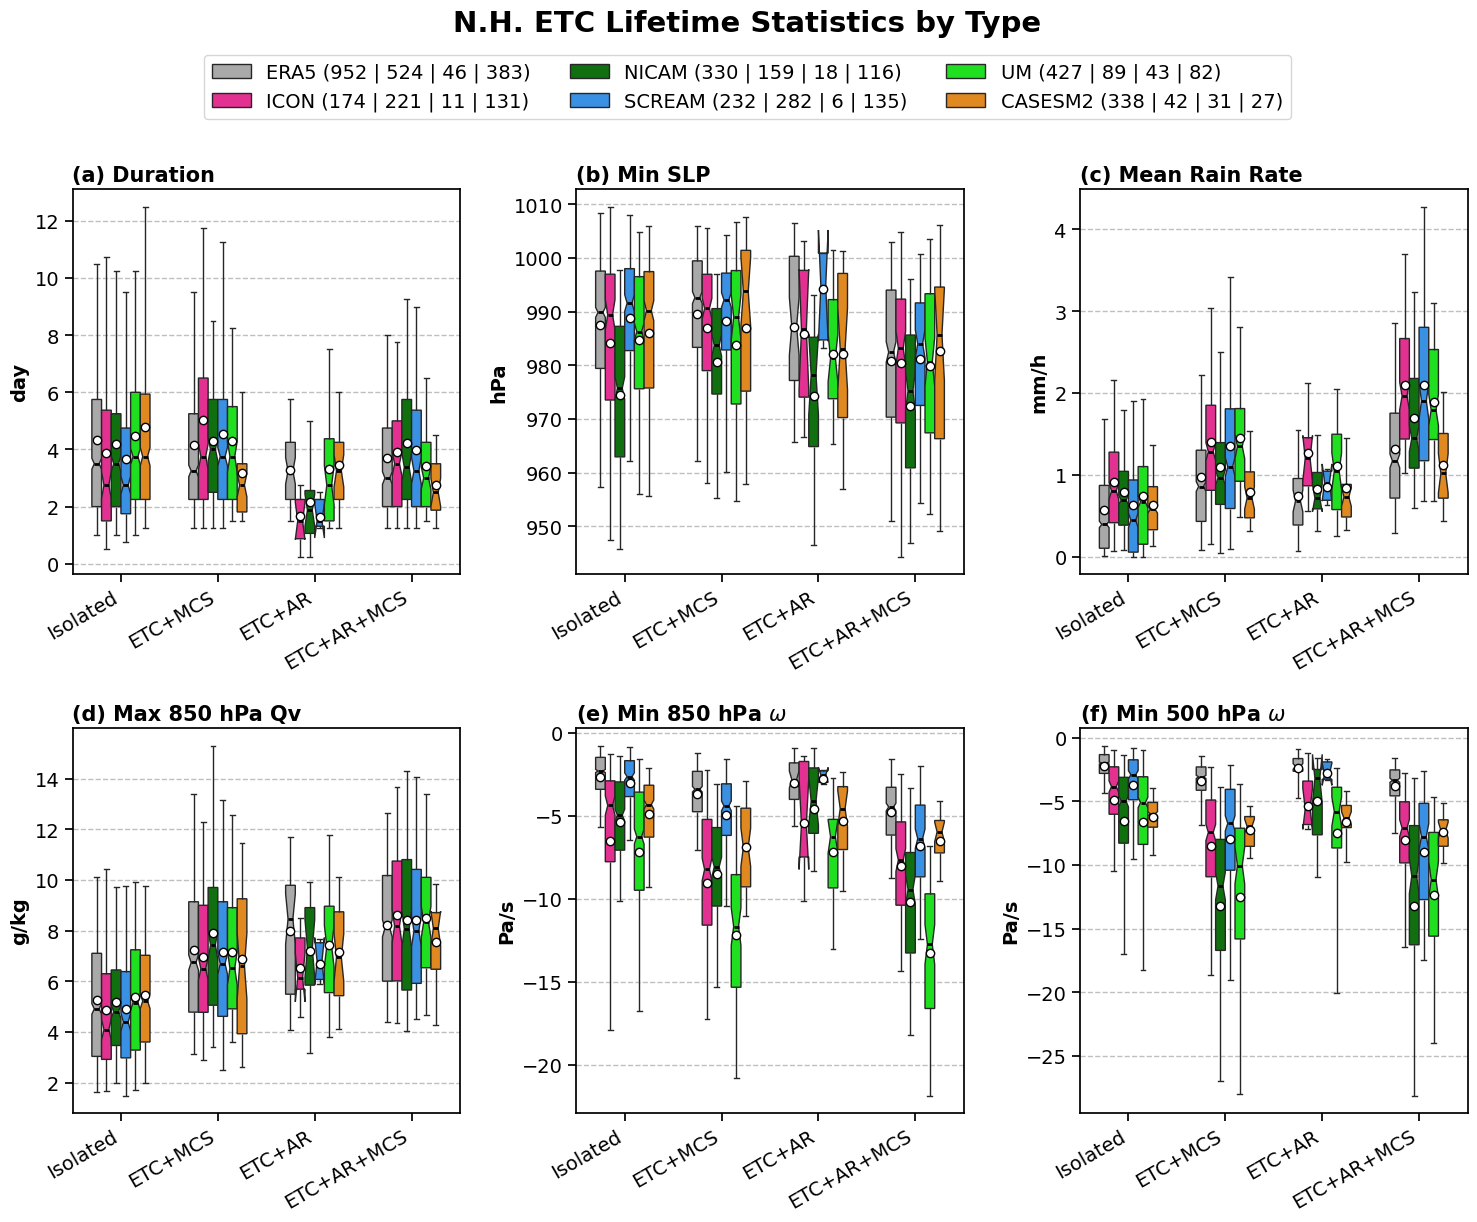

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_NH_lifetime_boxplot_by4ETCtypes_duration_psl_pr_hus850_omega850_omega500.png


In [12]:
# Define variables for Type 1 plots (2 rows × 3 columns)
type1_variables = [
    ['duration', 'psl_lifetime_min_hpa', 'pr_lifetime_max'],
    ['hus_850hPa_lifetime_max', 'omega_850hPa_lifetime_min', 'omega_500hPa_lifetime_min']
]
panel_titles = [
    ['(a) Duration', '(b) Min SLP', '(c) Mean Rain Rate'],
    ['(d) Max 850 hPa Qv', '(e) Min 850 hPa $\\omega$', '(f) Min 500 hPa $\\omega$']
]
panel_ylabels = [
    ['day', 'hPa', 'mm/h'],
    ['g/kg', 'Pa/s', 'Pa/s']
]
# Create color palette for sources using display names
source_colors_display = {source_display_names[k]: v for k, v in source_colors.items()}

# Define custom source order
source_order_custom = ['ERA5', 'ICON', 'NICAM', 'SCREAM', 'UM', 'CASESM2']

figname = f"{fig_dir}ETC_{hemisphere_suffix}_lifetime_boxplot_by4ETCtypes_duration_psl_pr_hus850_omega850_omega500.png"

# Create box plots
fig = plot_boxplots_by_etc_type(
    track_stats_nh,
    type1_variables,
    type1_var_labels,
    figsize=(18, 12),
    title=f"{lat_label} ETC Lifetime Statistics by Type",
    title_y=1.03,
    source_colors=source_colors_display,
    source_order=source_order_custom,
    box_width=0.6,
    xtick_rotation=30,
    notch=True,
    panel_titles=panel_titles,
    panel_ylabels=panel_ylabels,
    fontsize=14,
    legend_ncol=3,
    legend_y=1.0,
    hspace=0.4, wspace=0.3,
    figname=figname,
)
plt.show()

print(f"Figure saved: {figname}")


## Example: Type 2 Lifecycle Evolution (1 row × 2 columns, 4 ETC types each)

Variable 'psl_min' [row=0, col=0]: Median range=[981.50, 1008.48], ERA5 IQR=[977.74, 1009.41] -> ylim=(np.float64(976.1566464843751), np.float64(1010.9979126674108))
Variable 'pr_mean' [row=1, col=0]: Median range=[0.02, 1.14], ERA5 IQR=[0.00, 1.08] -> ylim=(np.float64(-0.054339535656617956), np.float64(1.1985901966749224))
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_NH_composite_lifecycle_by4ETCtypes_psl_pr.png


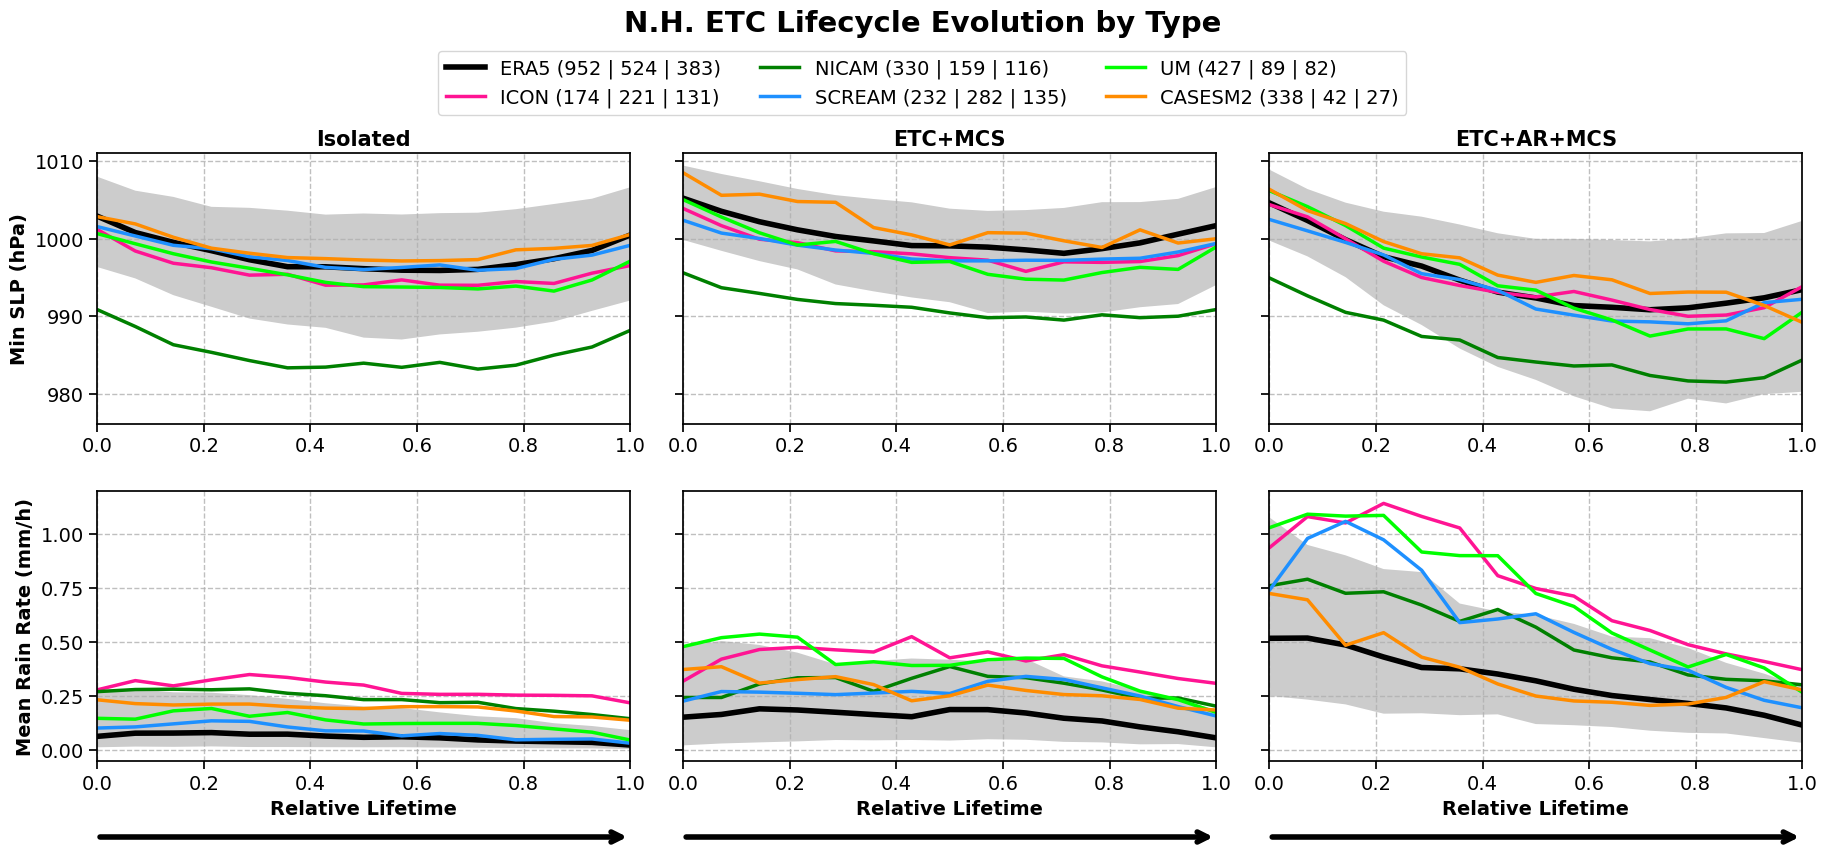

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_NH_composite_lifecycle_by4ETCtypes_psl_pr.png


In [13]:
# Define variables for Type 2 plots (2 rows × 1 column each, 4 ETC panels per variable)
type2_variables = [
    ['psl_min'],   # Row 0: SLP (will create 4 panels for 4 ETC types)
    ['pr_mean'],   # Row 1: Precip (will create 4 panels for 4 ETC types)
]
ylims = None
y_scaling = [
    [0.01],  # Row 0 (psl_min): convert Pa to hPa
    [1.0]    # Row 1 (pr_mean): no scaling
]
panel_ylabels = [
    ['Min SLP (hPa)'],
    ['Mean Rain Rate (mm/h)']
]
panel_titles = None
title_loc = 'center'
# Update the source colors for ERA5
line_colors = source_colors.copy()
line_colors['era5'] = 'black'  # ERA5 in black for lifecycle plots

# Define custom source order
source_order_custom = ['ERA5', 'ICON', 'NICAM', 'SCREAM', 'UM', 'CASESM2']

# Select ETC types to plot (can be a subset of the 4 types)
etc_types = ['Isolated', 'ETC+MCS', 'ETC+AR+MCS']

figname = f"{fig_dir}ETC_{hemisphere_suffix}_composite_lifecycle_by4ETCtypes_psl_pr.png"

# Create lifecycle evolution plots
fig = plot_lifecycle_evolution_by_etc_type(
    df_nh,
    track_stats_nh,
    type2_variables,
    type2_var_labels,
    etc_types=etc_types,
    source_colors=line_colors,
    source_order=source_order_custom,
    figsize=(22, 8),
    title=f"{lat_label} ETC Lifecycle Evolution by Type",
    title_y=1.06,
    n_steps=n_steps,
    ylims=ylims, y_scaling=y_scaling,
    panel_ylabels=panel_ylabels, panel_titles=panel_titles, title_loc=title_loc,
    fontsize=14,
    legend_ncol=3,
    legend_y=1.02,
    hspace=0.25, wspace=0.1, sps_hspace=0.1, sps_wspace=0.1,
    share_y=True,
    figname=figname,
)
plt.show()

print(f"Figure saved: {figname}")


## Example: Type 2 with All 6 Variables (2 rows × 3 columns)

In [14]:
track_stats_nh.omega_850hPa_lifetime_min.describe()

count    4922.000000
mean       -5.490371
std         4.255321
min       -62.529514
25%        -7.185839
50%        -4.312681
75%        -2.552754
max        -0.116528
Name: omega_850hPa_lifetime_min, dtype: float64

Variable 'psl_min' [row=0, col=0]: Median range=[981.50, 1008.48], ERA5 IQR=[977.74, 1009.41] -> ylim=(np.float64(976.1566464843751), np.float64(1010.9979126674108))
Variable 'pr_mean' [row=1, col=0]: Median range=[0.02, 1.14], ERA5 IQR=[0.00, 1.08] -> ylim=(np.float64(-0.054339535656617956), np.float64(1.1985901966749224))
Variable 'hus_850hPa_mean' [row=2, col=0]: Median range=[2.78, 7.73], ERA5 IQR=[1.79, 9.67] -> ylim=(np.float64(1.3966440618038178), np.float64(10.061622554063797))
Variable 'omega_850hPa_min' [row=3, col=0]: Median range=[-7.92, -0.75], ERA5 IQR=[-4.11, -0.45] -> ylim=(np.float64(-8.295412677526473), np.float64(-0.07238801802907674))
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_NH_composite_lifecycle_by4ETCtypes_psl_pr_hus850_omega850.png


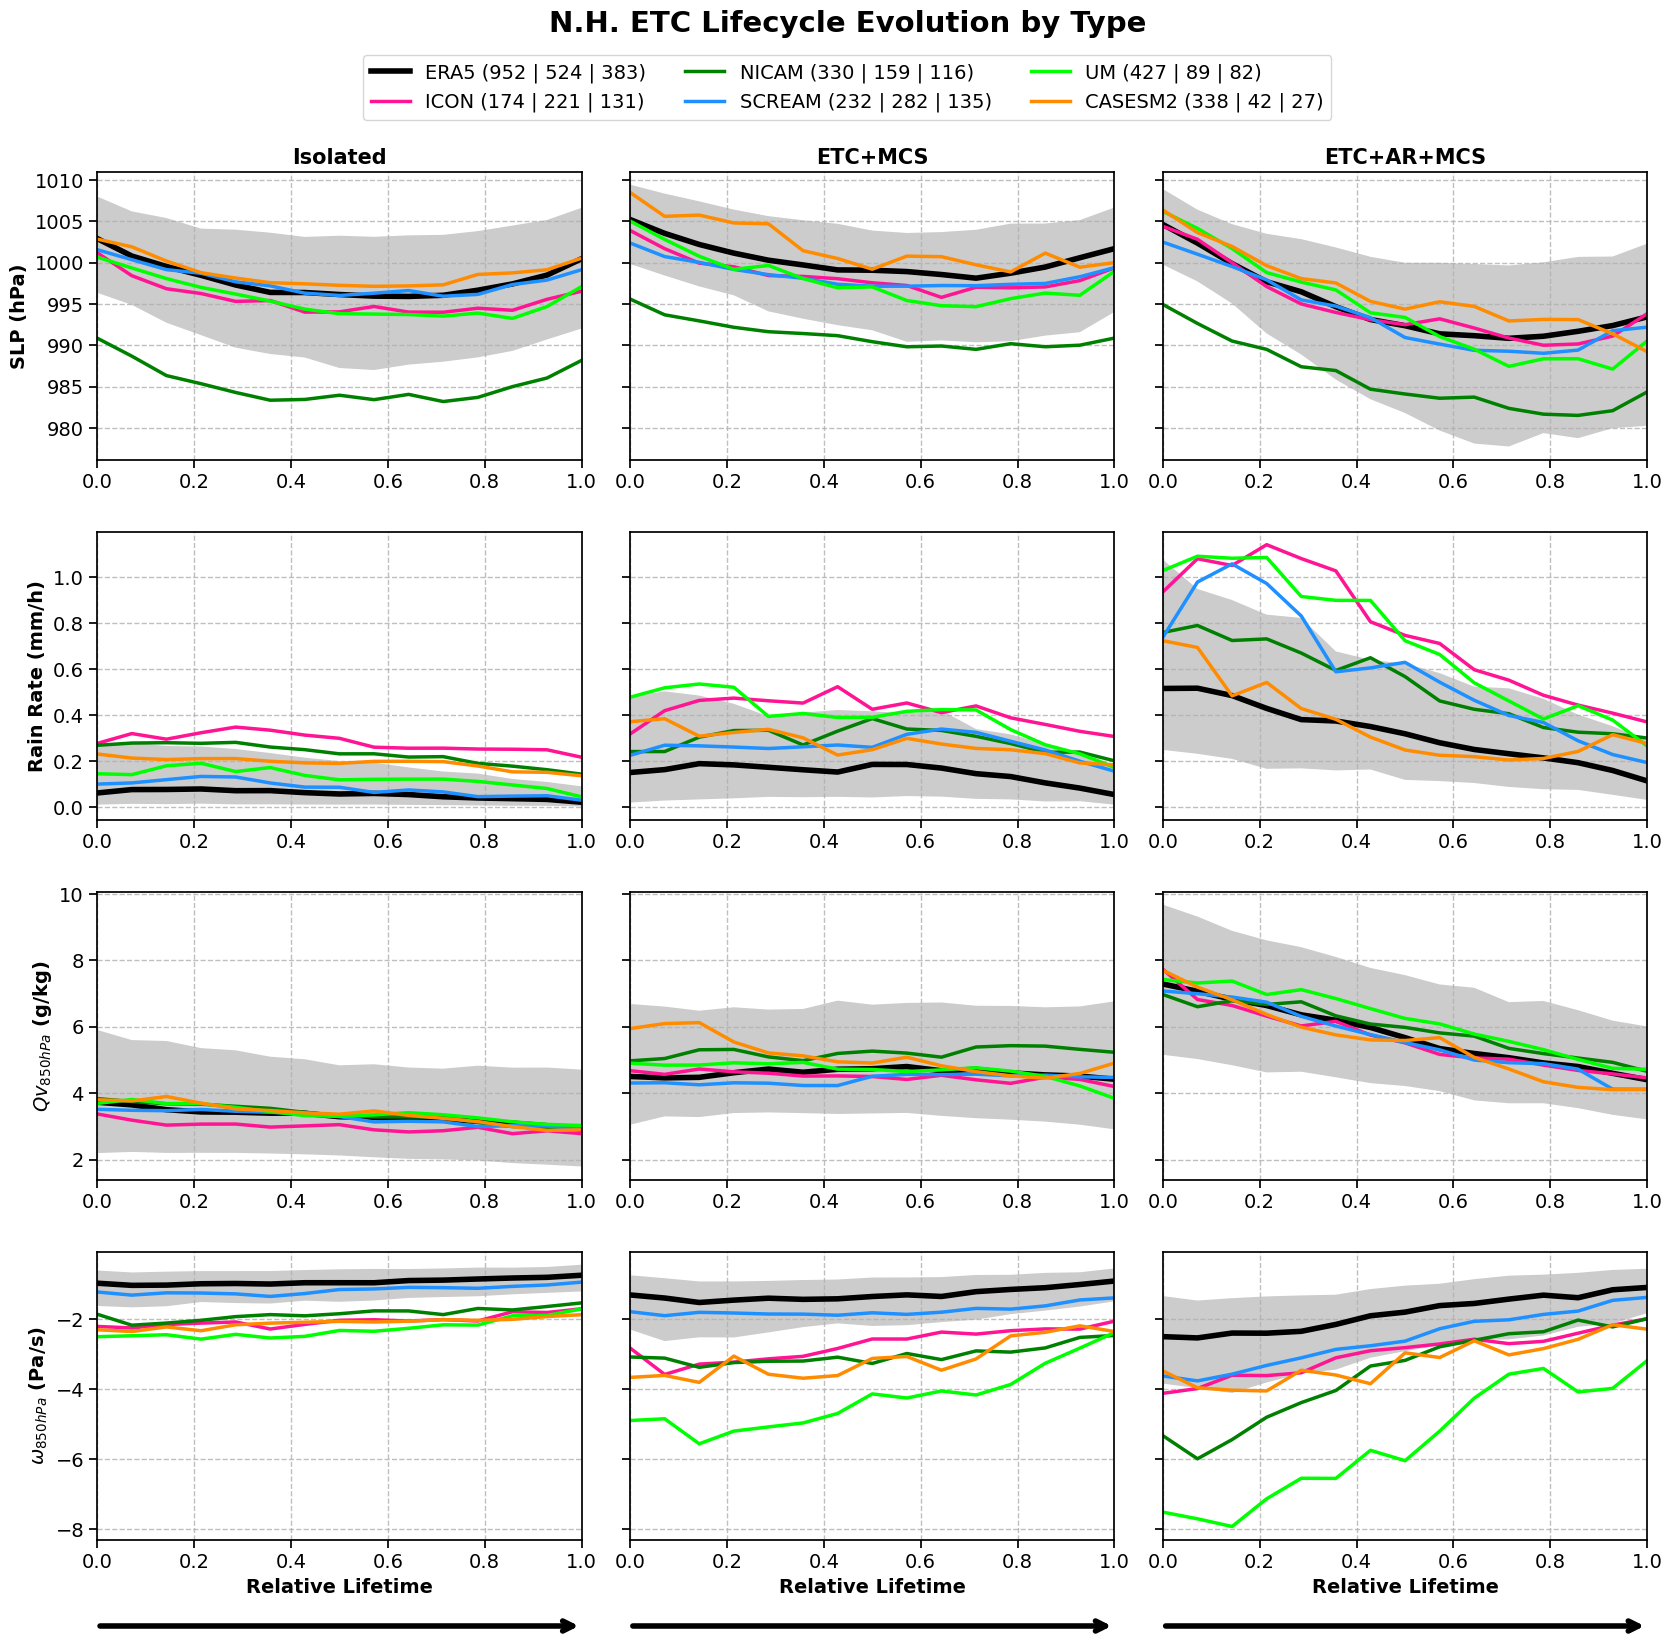

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_NH_composite_lifecycle_by4ETCtypes_psl_pr_hus850_omega850.png


In [15]:
# Define all variables for comprehensive lifecycle comparison
type2_variables = [
    ['psl_min'], ['pr_mean'], ['hus_850hPa_mean'], ['omega_850hPa_min'],
    # ['omega_850hPa_min'], ['omega_500hPa_min'],
]
ylims = None
y_scaling = [
    [0.01],  # Row 0 (psl_min): convert Pa to hPa
    [1.0],   # Row 1 (pr_mean): no scaling
    [1.0],   # Row 2 (hus_850hPa_mean): no scaling
    [1.0],   # Row 3 (omega_850hPa_min): no scaling
    # [1.0],   # Row 4 (omega_500hPa_min): no scaling
]
panel_ylabels = [
    ["SLP (hPa)"],
    ["Rain Rate (mm/h)"],
    ["$Qv_{850 hPa}$ (g/kg)"],
    [r"$\omega_{850 hPa}$ (Pa/s)"],
    # [r"$\omega_{500 hPa}$ (Pa/s)"],
]
panel_titles = None
title_loc = 'center'
# Update the source colors for ERA5
line_colors = source_colors.copy()
line_colors['era5'] = 'black'  # ERA5 in black for lifecycle plots

# Define custom source order
source_order_custom = ['ERA5', 'ICON', 'NICAM', 'SCREAM', 'UM', 'CASESM2']

# Select ETC types to plot (can be a subset of the 4 types)
etc_types = ['Isolated', 'ETC+MCS', 'ETC+AR+MCS']

# figname = f"{fig_dir}ETC_{hemisphere_suffix}_composite_lifecycle_by4ETCtypes_psl_pr_hus850_omega850_omega500.pdf"
figname = f"{fig_dir}ETC_{hemisphere_suffix}_composite_lifecycle_by4ETCtypes_psl_pr_hus850_omega850.png"

# Create lifecycle evolution plots
fig = plot_lifecycle_evolution_by_etc_type(
    df_nh,
    track_stats_nh,
    type2_variables,
    type2_var_labels,
    etc_types=etc_types,
    source_colors=line_colors,
    source_order=source_order_custom,
    figsize=(20, 18),
    title=f"{lat_label} ETC Lifecycle Evolution by Type",
    title_y=0.97,
    n_steps=n_steps,
    ylims=ylims, y_scaling=y_scaling,
    panel_ylabels=panel_ylabels, panel_titles=panel_titles, title_loc=title_loc,
    fontsize=14,
    legend_ncol=3,
    legend_y=0.95,
    hspace=0.25, wspace=0.3, sps_hspace=0.1, sps_wspace=0.1,
    arrow_y_loc=-0.3,
    share_y=True,
    figname=figname,
)
plt.show()

print(f"Figure saved: {figname}")


## Summary Statistics by Source and ETC Type

Statistics for the selected hemisphere.

In [16]:
# Summary statistics table
print("="*80)
print(f"{hemisphere} Track Count by Source and ETC Type")
print("="*80)
summary_counts = track_stats_nh.groupby(['source_display', 'overlap_type']).size().unstack(fill_value=0)
print(summary_counts)
print("\n")

print("="*80)
print("Mean Track Duration (hours) by Source and ETC Type")
print("="*80)
summary_duration = track_stats_nh.groupby(['source_display', 'overlap_type'])['duration'].mean().unstack()
print(summary_duration.round(1))
print("\n")

print("="*80)
print("Mean Lifetime-Min SLP (hPa) by Source and ETC Type")
print("="*80)
summary_psl = track_stats_nh.groupby(['source_display', 'overlap_type'])['psl_lifetime_min_hpa'].mean().unstack()
print(summary_psl.round(1))
print("\n")

print("="*80)
print("Mean Lifetime-Max Precip (mm/h) by Source and ETC Type")
print("="*80)
summary_pr = track_stats_nh.groupby(['source_display', 'overlap_type'])['pr_lifetime_max'].mean().unstack()
print(summary_pr.round(3))

NH Track Count by Source and ETC Type
overlap_type    ETC+AR  ETC+AR+MCS  ETC+MCS  Isolated
source_display                                       
CASESM2             31          27       42       338
ERA5                46         383      524       952
ICON                11         131      221       174
NICAM               18         116      159       330
SCREAM               6         135      282       232
UM                  43          82       89       427


Mean Track Duration (hours) by Source and ETC Type
overlap_type    ETC+AR  ETC+AR+MCS  ETC+MCS  Isolated
source_display                                       
CASESM2            3.5         2.8      3.2       4.8
ERA5               3.3         3.7      4.1       4.3
ICON               1.7         3.9      5.0       3.9
NICAM              2.2         4.2      4.3       4.2
SCREAM             1.6         4.0      4.6       3.7
UM                 3.3         3.4      4.3       4.5


Mean Lifetime-Min SLP (hPa) by Source and E

## Data Organization Summary

### DataFrame Structure:

**`df_all` / `df_nh`** (Time-series data):
- Rows: Individual time points for all tracks across all sources
- Key columns: `source`, `storm_id`, `time`, `psl_min`, `pr_mean`, `overlap_flag`, etc.
- Usage: Lifecycle evolution analysis (interpolate each track to relative time)

**`track_stats_all` / `track_stats_nh`** (Track-level statistics):
- Rows: One row per track (aggregated over lifetime)
- Key columns: `source`, `storm_id`, `duration`, `psl_lifetime_min`, `dominant_overlap_flag`, `overlap_type`, etc.
- Usage: Box plots, statistical comparisons across sources and ETC types

### Advantages of This Approach:
1. **Easy filtering**: `df[df['source'] == 'era5']` or `df[df['overlap_type'] == 'ETC+AR']`
2. **Seaborn integration**: Use `hue='source_display'` directly
3. **Flexible groupby**: `df.groupby(['source', 'overlap_type'])['variable'].mean()`
4. **Unified analysis**: All sources in one DataFrame for consistent operations

### Plotting Functions:
- **Type 1**: `plot_boxplots_by_etc_type()` - Multi-panel box plots with flexible layout
- **Type 2**: `plot_lifecycle_evolution_by_etc_type()` - Multi-panel lifecycle evolution with ERA5 highlighting

## ETC Type Difference Significance Test

For each dataset and each ETC lifetime statistics variable, compute the **mean % difference** of the three COF types (ETC+MCS, ETC+AR, ETC+AR+MCS) relative to the **Isolated** baseline, together with a **statistical significance test**.

### Method
| Aspect | Choice |
|---|---|
| Comparison | Each non-isolated ETC type vs. Isolated |
| % difference | `(mean_type − mean_isolated) / abs(mean_isolated) × 100` |
| Significance test | **Mann-Whitney U** (two-sided, Wilcoxon rank-sum); chosen because precipitation and area variables are heavily right-skewed and non-Gaussian |
| Significance threshold | α = 0.05 |

### Table layout
* **Rows** — ETC lifetime statistics variables
* **Columns** — datasets (ERA5, SCREAM, ICON, UM, NICAM, CASESM2)
* **Cell content** — three lines, one per non-isolated ETC type: `M: +49%`
  A ✘ symbol is appended only when the result is **not** significant at α = 0.05 (e.g. `M: +49% ✘`); no symbol means significant.
  Labels: `M` = ETC+MCS, `A` = ETC+AR, `A+M` = ETC+AR+MCS


In [17]:
from scipy import stats as scipy_stats
from IPython.display import display, HTML

# ── Settings ──────────────────────────────────────────────────────────────────
ETC_STAT_VARS = [
    'duration',
    'psl_lifetime_min_hpa',
    'pr_lifetime_max',
    'hus_850hPa_lifetime_max',
    'omega_850hPa_lifetime_min',
    'omega_500hPa_lifetime_min',
]

ETC_VAR_LABELS = {
    'duration':                 'Duration',
    'psl_lifetime_min_hpa':     'Min SLP',
    'pr_lifetime_max':          'Max Rain Rate',
    'hus_850hPa_lifetime_max':  'Max 850 hPa Humidity',
    'omega_850hPa_lifetime_min':'Min 850 hPa Omega',
    'omega_500hPa_lifetime_min':'Min 500 hPa Omega',
}

ETC_DATASET_ORDER = ['ERA5', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2']

# (overlap_type value, short label)
ETC_COF_COMPARE = [('ETC+MCS', 'M'), ('ETC+AR', 'A'), ('ETC+AR+MCS', 'A+M')]

ETC_ALPHA  = 0.05
ETC_NONSIG = '✘'    # only shown when not significant
ETC_MIN_N  = 5      # minimum sample size per group


# ── Core computation ──────────────────────────────────────────────────────────
def compute_etc_sig_table(df, stat_vars, dataset_order, cof_compare, alpha, min_n):
    """
    Compute % mean difference and Mann-Whitney U significance for each
    non-isolated ETC type vs. Isolated, per variable and dataset.
    Returns dict[var][ds] = list of (pct_str, is_sig).
    """
    data = {}
    for var in stat_vars:
        data[var] = {}
        for ds in dataset_order:
            df_ds    = df[df['source_display'] == ds]
            isolated = df_ds[df_ds['overlap_type'] == 'Isolated'][var].dropna()
            iso_mean = isolated.mean()

            comparisons = []
            for cot, label in cof_compare:
                other = df_ds[df_ds['overlap_type'] == cot][var].dropna()

                if (len(isolated) < min_n or len(other) < min_n
                        or iso_mean == 0 or (isinstance(iso_mean, float) and np.isnan(iso_mean))):
                    comparisons.append(('N/A', None))
                    continue

                pct_diff = (other.mean() - iso_mean) / abs(iso_mean) * 100
                pct_str  = f'{pct_diff:+.0f}%'

                # For PSL, compute the % difference relative to the 10-90 percentile range of the isolated group
                # This accounts for the fact that a 5 hPa difference is more meaningful if the typical range is 50 hPa than the mean value of 990 hPa.
                if 'psl' in var:      
                    iso_range = np.abs(isolated.quantile(0.90) - isolated.quantile(0.10))
                    pct_diff = (other.mean() - iso_mean) / iso_range * 100
                    pct_str  = f'{pct_diff:+.0f}%'  # rounded to integer

                # Mann-Whitney U test (two-sided, non-parametric)
                _, p = scipy_stats.mannwhitneyu(other, isolated, alternative='two-sided')
                is_sig = p < alpha

                comparisons.append((pct_str, is_sig))

            data[var][ds] = comparisons
    return data


# ── HTML table builder ────────────────────────────────────────────────────────
_ETC_CSS = """
<style>
.etcsigtab {
    border-collapse: collapse;
    font-size: 12px;
    font-family: Arial, sans-serif;
    margin-bottom: 20px;
}
.etcsigtab th {
    background-color: #4472C4;
    color: white;
    font-weight: bold;
    padding: 6px 10px;
    border: 1px solid #ccc;
    text-align: center;
}
.etcsigtab td {
    border: 1px solid #ccc;
    padding: 5px 8px;
    text-align: center;
    vertical-align: top;
    line-height: 1.6;
    background-color: #ffffff;
}
.etcsigtab td.varname {
    text-align: left;
    font-weight: bold;
    color: #000000;
    background-color: #ffffff;
    white-space: nowrap;
}
.etc-pct-pos  { color: #c0392b; }
.etc-pct-neg  { color: #2471a3; }
.etc-pct-na   { color: #999; }
.etc-nonsig   { color: #000000; }
</style>
"""

def _etc_pct_span(pct_str):
    if pct_str == 'N/A':
        return '<span class="etc-pct-na">–</span>'
    cls = 'etc-pct-pos' if pct_str.startswith('+') else 'etc-pct-neg'
    return f'<span class="{cls}">{pct_str}</span>'


def build_etc_html_table(data, stat_vars, var_labels, dataset_order, cof_compare, title):
    html = _ETC_CSS + f'<h3 style="font-family:Arial;color:#000">{title}</h3>\n'
    html += '<table class="etcsigtab"><thead><tr>'
    html += '<th>Variable</th>'
    for ds in dataset_order:
        html += f'<th>{ds}</th>'
    html += '</tr></thead><tbody>\n'

    for var in stat_vars:
        html += '<tr>'
        html += f'<td class="varname">{var_labels[var]}</td>'

        for ds in dataset_order:
            comparisons = data[var][ds]
            lines = []
            for i, (cot, label) in enumerate(cof_compare):
                pct_str, is_sig = comparisons[i]
                lbl_html = f'<span style="color:#000">{label}:</span>'
                if is_sig is None or is_sig:
                    line = f'{lbl_html} {_etc_pct_span(pct_str)}'
                else:
                    line = (f'{lbl_html} {_etc_pct_span(pct_str)} '
                            f'<span class="etc-nonsig">{ETC_NONSIG}</span>')
                lines.append(line)
            html += f'<td>{"<br>".join(lines)}</td>'

        html += '</tr>\n'

    html += '</tbody></table>'
    return html


# ── Run ───────────────────────────────────────────────────────────────────────
etc_data = compute_etc_sig_table(
    track_stats_nh, ETC_STAT_VARS, ETC_DATASET_ORDER, ETC_COF_COMPARE, ETC_ALPHA, ETC_MIN_N
)

etc_title = (
    f'{lat_label} ETC — Mean % Difference vs Isolated '
    f'(Mann-Whitney U, α={ETC_ALPHA}; ✘ = not significant at p < {ETC_ALPHA})'
)
etc_html_table = build_etc_html_table(
    etc_data, ETC_STAT_VARS, ETC_VAR_LABELS, ETC_DATASET_ORDER, ETC_COF_COMPARE, title=etc_title,
)
display(HTML(etc_html_table))


Variable,ERA5,SCREAM,ICON,UM,NICAM,CASESM2
Duration,M: -4% ✘A: -24% ✘A+M: -15%,M: +24%A: -56%A+M: +9%,M: +30%A: -57%A+M: +2%,M: -4% ✘A: -26%A+M: -23%,M: +3% ✘A: -49%A+M: +0% ✘,M: -34%A: -28% ✘A+M: -43%
Min SLP,M: +6%A: -1% ✘A+M: -18%,M: -2% ✘A: +15% ✘A+M: -22%,M: +5% ✘A: +3% ✘A+M: -7%,M: -2% ✘A: -7% ✘A+M: -13%,M: +14%A: -0% ✘A+M: -4% ✘,M: +2% ✘A: -9% ✘A+M: -8% ✘
Max Rain Rate,M: +71%A: +32%A+M: +132%,M: +116%A: +35% ✘A+M: +234%,M: +53%A: +38% ✘A+M: +129%,M: +98%A: +51%A+M: +156%,M: +39%A: +5% ✘A+M: +114%,M: +25%A: +32%A+M: +76%
Max 850 hPa Humidity,M: +37%A: +51%A+M: +56%,M: +46%A: +36%A+M: +71%,M: +43%A: +35%A+M: +77%,M: +33%A: +38%A+M: +58%,M: +53%A: +39%A+M: +63%,M: +26%A: +31%A+M: +39%
Min 850 hPa Omega,M: -39%A: -14% ✘A+M: -79%,M: -63%A: +9% ✘A+M: -124%,M: -38%A: +17% ✘A+M: -23%,M: -70%A: +0% ✘A+M: -85%,M: -58%A: +14% ✘A+M: -90%,M: -41%A: -9% ✘A+M: -34%
Min 500 hPa Omega,M: -56%A: -7% ✘A+M: -72%,M: -116%A: +25% ✘A+M: -142%,M: -74%A: -10% ✘A+M: -64%,M: -89%A: -13% ✘A+M: -87%,M: -101%A: +24% ✘A+M: -102%,M: -17%A: -7% ✘A+M: -20%


In [18]:
# ── Save table as standalone HTML file (for use in Microsoft Word) ────────────
_ETC_HTML_WRAP = """\
<!DOCTYPE html>
<html><head>
<meta charset="utf-8">
<title>{title}</title>
</head><body>
{body}
</body></html>
"""

out_path = os.path.join(fig_dir, f'Table_ETC_sig_{hemisphere_suffix}.html')
with open(out_path, 'w', encoding='utf-8') as fh:
    fh.write(_ETC_HTML_WRAP.format(
        title=f'ETC Significance Table — {lat_label} ({hemisphere_suffix})',
        body=etc_html_table,
    ))
print(f"Saved: {out_path}")

print("\nTo use in Word:")
print("  Option 1 — open the .html file directly in Word (File → Open → select .html).")
print("  Option 2 — open in a browser, select the full table, copy (Ctrl+C), paste into Word.")


Saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/Table_ETC_sig_NH.html

To use in Word:
  Option 1 — open the .html file directly in Word (File → Open → select .html).
  Option 2 — open in a browser, select the full table, copy (Ctrl+C), paste into Word.
